In [1]:
import statistics
import pandas as pd
import equity as eq
import equity_strats as eq_strats
import matplotlib.pyplot as plt
import math

In [2]:
AAPL_options_csv = 'apple_options.csv'
AAPL_underlying_csv = 'apple_stocks.csv'
AAPL_options = pd.read_csv(AAPL_options_csv, parse_dates = ["exdate", "date"])
AAPL_underlying = pd.read_csv(AAPL_underlying_csv, parse_dates = ["date"])
risk_free = pd.read_csv("DGS10.csv", parse_dates = ["DATE"])

In [3]:
file_hedge = open("hedged.txt", "w")
file_no_hedge = open("not_hedged.txt", "w")

daily_returns_hedged = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, pd.Timestamp(2018,4,11), 5, 180, file=file_hedge)
daily_returns_no_hedge = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, pd.Timestamp(2018,4,11), 5, 180, hedging=False, file=file_no_hedge)
file_hedge.close()
file_no_hedge.close()

[('AAPL 181019C180000', 'AAPL 181019P180000'), ('AAPL 181019C180000', 'AAPL 181019P180000'), ('AAPL 181019C180000', 'AAPL 181019P180000'), ('AAPL 181019C180000', 'AAPL 181019P180000'), ('AAPL 181019C180000', 'AAPL 181019P180000')]
AAPL 181019C180000
AAPL 181019P180000
AAPL 181019C180000
AAPL 181019P180000
AAPL 181019C180000
AAPL 181019P180000
AAPL 181019C180000
AAPL 181019P180000
AAPL 181019C180000
AAPL 181019P180000
LOOOK 2018-04-11 00:00:00
LOOOK 2018-04-11 00:00:00
LOOOK 2018-04-11 00:00:00
LOOOK 2018-04-11 00:00:00
LOOOK 2018-04-11 00:00:00
LOOOK 2018-04-11 00:00:00
LOOOK 2018-04-11 00:00:00
LOOOK 2018-04-11 00:00:00
LOOOK 2018-04-11 00:00:00
LOOOK 2018-04-11 00:00:00
2018-04-11 00:00:00
Premium pnl: -12412.5
Premium costs: 12412.5
Number of stocks: 0
Stock pnl: 0.0
Stock costs: 0
Total pnl: -12412.5
Total costs: 12412.5
Total real pnl: 0.0
Spot price: 172.44
Number of stocks before hedge: 0
Delta before hedge: -0.4698484110993556
This
Hedge count: -47
Delta after hedge: 0.00015158

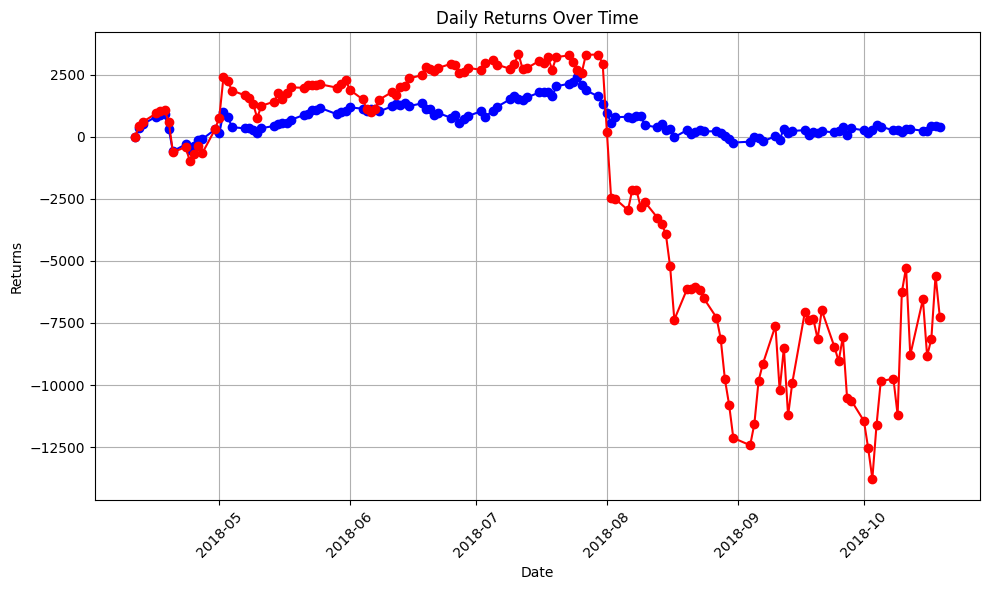

609.3003217587981
9672.342750752501
658.7783158518591
1.0812046085093776
0.06810948834506579
5184.493593112637
82301.28432710239
-2094.1296296296296
-0.4039217316058766
-0.02544467740389828


In [4]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(daily_returns_hedged.index, daily_returns_hedged.values, marker='o', linestyle='-', color='b')  # Plot daily returns
plt.plot(daily_returns_hedged.index, daily_returns_no_hedge.values, marker='o', linestyle='-', color='r')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

stdev = statistics.stdev(daily_returns_hedged)
stdev_annual = stdev * math.sqrt(252)
mean = statistics.mean(daily_returns_hedged)
print(stdev)
print(stdev_annual)
print(mean)
print(mean/stdev)
print(mean/stdev_annual)

stdev = statistics.stdev(daily_returns_no_hedge)
stdev_annual = stdev * math.sqrt(252)
mean = statistics.mean(daily_returns_no_hedge)
print(stdev)
print(stdev_annual)
print(mean)
print(mean/stdev)
print(mean/stdev_annual)

In [ ]:
end_date1 = daily_returns_hedged.index[-1]
daily_returns2 = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, end_date1, 5, 180)
daily_returns2_no_hedge = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, end_date1, 5, 180, hedging = False)
end_date2 = daily_returns2.index[-1]

In [ ]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(daily_returns2.index, daily_returns2.values, marker='o', linestyle='-', color='b')  # Plot daily returns
plt.plot(daily_returns2.index, daily_returns2_no_hedge.values, marker='o', linestyle='-', color='r')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

stdev = statistics.stdev(daily_returns2)
stdev_annual = stdev * math.sqrt(252)
mean = statistics.mean(daily_returns2)
print(stdev)
print(stdev_annual)
print(mean)
print(mean/stdev)
print(mean/stdev_annual)

stdev = statistics.stdev(daily_returns2_no_hedge)
stdev_annual = stdev * math.sqrt(252)
mean = statistics.mean(daily_returns2_no_hedge)
print(stdev)
print(stdev_annual)
print(mean)
print(mean/stdev)
print(mean/stdev_annual)

In [ ]:
daily_returns3 = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, end_date2, 5, 180)
daily_returns3_no_hedge = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, end_date2, 5, 180, hedging = False)
end_date3 = daily_returns3.index[-1]

In [ ]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(daily_returns3.index, daily_returns3.values, marker='o', linestyle='-', color='b')  # Plot daily returns
plt.plot(daily_returns3.index, daily_returns3_no_hedge.values, marker='o', linestyle='-', color='r')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

stdev = statistics.stdev(daily_returns3)
stdev_annual = stdev * math.sqrt(252)
mean = statistics.mean(daily_returns3)
print(stdev)
print(stdev_annual)
print(mean)
print(mean/stdev)
print(mean/stdev_annual)

stdev = statistics.stdev(daily_returns3_no_hedge)
stdev_annual = stdev * math.sqrt(252)
mean = statistics.mean(daily_returns3_no_hedge)
print(stdev)
print(stdev_annual)
print(mean)
print(mean/stdev)
print(mean/stdev_annual)

In [ ]:
daily_returns4 = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, end_date3, 5, 180)
daily_returns4_no_hedge = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, end_date3, 5, 180, hedging = False)
end_date4 = daily_returns4.index[-1]

In [ ]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(daily_returns4.index, daily_returns4.values, marker='o', linestyle='-', color='b')  # Plot daily returns
plt.plot(daily_returns4.index, daily_returns4_no_hedge.values, marker='o', linestyle='-', color='r')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

stdev = statistics.stdev(daily_returns4)
stdev_annual = stdev * math.sqrt(252)
mean = statistics.mean(daily_returns4)
print(stdev)
print(stdev_annual)
print(mean)
print(mean/stdev)
print(mean/stdev_annual)

stdev = statistics.stdev(daily_returns4_no_hedge)
stdev_annual = stdev * math.sqrt(252)
mean = statistics.mean(daily_returns4_no_hedge)
print(stdev)
print(stdev_annual)
print(mean)
print(mean/stdev)
print(mean/stdev_annual)

In [ ]:
daily_returns5 = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, end_date4, 5, 180)
daily_returns5_no_hedge = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, end_date4, 5, 180, hedging = False)
end_date5 = daily_returns5.index[-1]

In [ ]:
daily_returns6 = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, end_date5, 10, 180)
end_date6 = daily_returns6.index[-1]

In [ ]:
daily_returns7 = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, end_date6, 10, 180)
end_date7 = daily_returns7.index[-1]

In [ ]:
daily_returns8 = eq_strats.backtest_short_straddle_with_premium_change(AAPL_options_csv, AAPL_underlying_csv, AAPL_options, AAPL_underlying, risk_free, end_date7, 10, 180)